# 1. Database Connection & Data Inspection

Sebelum menentukan rumusan masalah dan target pemodelan machine learning, kita membaca langsung basis data SQLite `superstore.sqlite` menggunakan library `sqlite3` dan `pandas` untuk memeriksa struktur tabel, kolom, serta tipe data yang tersedia.

In [1]:
import sqlite3
import pandas as pd

# Hubungkan ke file SQLite di folder notebook
db_path = "superstore.sqlite"
conn = sqlite3.connect(db_path)

# 1. Cek semua nama tabel yang ada di dalam database
query_tables = "SELECT name FROM sqlite_master WHERE type='table';"
tables = pd.read_sql_query(query_tables, conn)
print("=== DAFTAR TABEL DI DATABASE ===")
print(tables)

=== DAFTAR TABEL DI DATABASE ===
                        name
0              dim_customers
1               dim_products
2  dim_product_name_variants
3              dim_locations
4                     orders
5                order_items


**Penjelasan Tabel:**
Database SQLite ini dinormalisasi ke dalam beberapa tabel dimensi dan fakta:
- `orders`: Menyimpan informasi nomor order, tanggal transaksi, moda kirim, dan prioritas order.
- `order_items`: Menyimpan metrik transaksi produk individual (penjualan, profit, diskon, kuantitas, ongkos kirim).
- `dim_customers`: Menyimpan identitas pelanggan dan segmen pasar.
- `dim_products`: Menyimpan nama produk, kategori, dan sub-kategori.
- `dim_locations`: Menyimpan lokasi pengiriman (kota, negara, region, market).

In [2]:
# Query SQL untuk menggabungkan tabel-tabel utama sesuai skema relasi
query_join = """
SELECT 
    oi.row_id,
    oi.order_key,
    o.order_date,
    o.ship_date,
    o.ship_mode,
    o.order_priority,
    c.customer_id,
    c.customer_name,
    c.segment,
    p.product_id,
    p.category,
    p.sub_category,
    p.product_name,
    l.city,
    l.state,
    l.country,
    l.region,
    l.market,
    oi.sales,
    oi.quantity,
    oi.discount,
    oi.profit,
    oi.shipping_cost
FROM order_items oi
JOIN orders o ON oi.order_key = o.order_key
JOIN dim_customers c ON o.customer_id = c.customer_id
JOIN dim_products p ON oi.product_id = p.product_id
JOIN dim_locations l ON o.location_id = l.location_id;
"""

df = pd.read_sql_query(query_join, conn)

# Tutup koneksi SQLite setelah data terbaca ke RAM
conn.close()

# Tampilkan informasi bentuk dataset dan 5 baris data teratas
print(f"Dataset berhasil dimuat: {df.shape[0]} baris dan {df.shape[1]} kolom.")
df.head()

Dataset berhasil dimuat: 51290 baris dan 23 kolom.


,row_id,order_key,order_date,ship_date,ship_mode,order_priority,customer_id,customer_name,segment,product_id,...,city,state,country,region,market,sales,quantity,discount,profit,shipping_cost
0,1,MX-2014-143658_SC-205753,2014-10-02 00:00:00,2014-10-06 00:00:00,Standard Class,Medium,SC-205753,Sonia Cooley,Consumer,OFF-LA-10002782,...,Mexico City,Distrito Federal,Mexico,North,LATAM,13.0,3,0.0,4.56,1.033
1,2,MX-2012-155047_KW-165703,2012-10-15 00:00:00,2012-10-20 00:00:00,Standard Class,Medium,KW-165703,Kelly Williams,Consumer,FUR-FU-10004015,...,Dos Quebradas,Risaralda,Colombia,South,LATAM,252.0,8,0.0,90.72,13.449
2,3,MX-2012-155047_KW-165703,2012-10-15 00:00:00,2012-10-20 00:00:00,Standard Class,Medium,KW-165703,Kelly Williams,Consumer,FUR-BO-10002352,...,Dos Quebradas,Risaralda,Colombia,South,LATAM,193.0,2,0.0,54.08,9.627
3,4,MX-2012-155047_KW-165703,2012-10-15 00:00:00,2012-10-20 00:00:00,Standard Class,Medium,KW-165703,Kelly Williams,Consumer,OFF-BI-10004428,...,Dos Quebradas,Risaralda,Colombia,South,LATAM,35.0,4,0.0,4.96,1.371
4,5,MX-2012-155047_KW-165703,2012-10-15 00:00:00,2012-10-20 00:00:00,Standard Class,Medium,KW-165703,Kelly Williams,Consumer,OFF-AR-10004594,...,Dos Quebradas,Risaralda,Colombia,South,LATAM,72.0,2,0.0,11.44,3.787


In [3]:
# 1. Cek tipe data dan kelengkapan kolom
print("=== INFO STRUKTUR DATA ===")
df.info()

=== INFO STRUKTUR DATA ===
<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   row_id          51290 non-null  int64  
 1   order_key       51290 non-null  str    
 2   order_date      51290 non-null  str    
 3   ship_date       51290 non-null  str    
 4   ship_mode       51290 non-null  str    
 5   order_priority  51290 non-null  str    
 6   customer_id     51290 non-null  str    
 7   customer_name   51290 non-null  str    
 8   segment         51290 non-null  str    
 9   product_id      51290 non-null  str    
 10  category        51290 non-null  str    
 11  sub_category    51290 non-null  str    
 12  product_name    51290 non-null  str    
 13  city            51290 non-null  str    
 14  state           51290 non-null  str    
 15  country         51290 non-null  str    
 16  region          51290 non-null  str    
 17  market         

In [4]:
# 2. Cek apakah ada nilai yang hilang (missing values)
print("\n=== MISSING VALUES PER KOLOM ===")
print(df.isnull().sum())


=== MISSING VALUES PER KOLOM ===
row_id            0
order_key         0
order_date        0
ship_date         0
ship_mode         0
order_priority    0
customer_id       0
customer_name     0
segment           0
product_id        0
category          0
sub_category      0
product_name      0
city              0
state             0
country           0
region            0
market            0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
dtype: int64


In [5]:
# 3. Cek statistik angka (angka negatif pada profit, diskon, dll.)
print("\n=== RINGKASAN STATISTIK NUMERIK ===")
df[['sales', 'quantity', 'discount', 'profit', 'shipping_cost']].describe()


=== RINGKASAN STATISTIK NUMERIK ===


,sales,quantity,discount,profit,shipping_cost
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,246.498440,3.476545,0.142908,28.610982,26.375818
std,487.567175,2.278766,0.212280,174.340972,57.296810
min,0.000000,1.000000,0.000000,-6599.978000,0.002000
25%,31.000000,2.000000,0.000000,0.000000,2.610000
50%,85.000000,3.000000,0.000000,9.240000,7.790000
75%,251.000000,5.000000,0.200000,36.810000,24.450000
max,22638.000000,14.000000,0.850000,8399.976000,933.570000


In [6]:
print("Distribusi Order Priority:")
print(df['order_priority'].value_counts())

print("\nDistribusi Segment Pelanggan:")
print(df['segment'].value_counts())

print("\nCek Proporsi Profit (Untung vs Rugi):")
is_profitable = (df['profit'] > 0).value_counts(normalize=True) * 100
print(is_profitable)

Distribusi Order Priority:
order_priority
Medium      29434
High        15500
Critical     3932
Low          2424
Name: count, dtype: int64

Distribusi Segment Pelanggan:
segment
Consumer       26518
Corporate      15429
Home Office     9343
Name: count, dtype: int64

Cek Proporsi Profit (Untung vs Rugi):
profit
True     74.240593
False    25.759407
Name: proportion, dtype: float64


In [7]:
# Bandingkan rata-rata diskon saat transaksi RUGI vs UNTUNG
df.groupby(df['profit'] > 0)[['discount', 'shipping_cost', 'sales']].mean()

,discount,shipping_cost,sales
profit,,,
False,0.429925,21.412658,200.026567
True,0.043320,28.097896,262.622879


## 2. Rumusan Masalah & Tujuan Pemodelan (Business Objectives)

Berdasarkan inspeksi data awal, ditemukan bahwa **~26% transaksi mengalami kerugian**, yang utamanya dipicu oleh **pemberian diskon yang terlalu besar (rata-rata mencapai 43%)**. Selain itu, nilai transaksi (`sales`) juga sangat bervariasi dari puluhan hingga puluhan ribu dollar.

Oleh karena itu, proyek ini akan membangun 2 model *Machine Learning* yang akan bekerja berdampingan:
1. **Model Klasifikasi (Prediksi Profitability):** Bertugas sebagai sistem deteksi dini (*early warning system*) untuk menebak apakah pesanan yang masuk akan berujung **Untung (1)** atau **Rugi (0)** berdasarkan kombinasi diskon, kuantitas, biaya kirim, dan profil pelanggan.
2. **Model Regresi (Prediksi Sales):** Bertugas memprediksi estimasi omzet/pendapatan yang akan didapat dari pesanan tersebut.

**Skenario Penggunaan Sistem:** 
Ketika ada pesanan masuk dengan permintaan diskon tinggi, sistem Regresi akan menebak potensi omzetnya, sementara sistem Klasifikasi akan memberi *flag* jika pesanan berpotensi rugi. Manajer kemudian bisa menggunakan wawasan ini untuk menyesuaikan angka diskon sebelum pesanan diproses.

## 3. Exploratory Data Analysis (EDA)
Pada tahap ini, kita akan membuat visualisasi data untuk mencari korelasi antar variabel dan membuktikan hipotesis awal mengenai penyebab kerugian transaksi.

Kolom angka yang terdeteksi otomatis: ['row_id', 'sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'is_profitable']


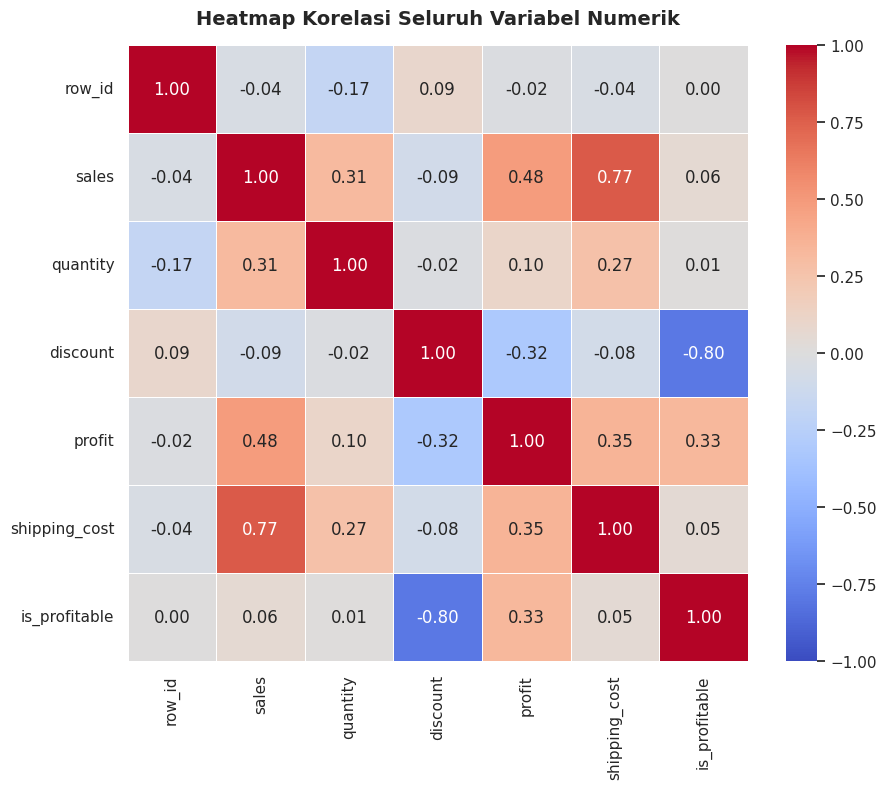

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

if 'is_profitable' not in df.columns:
    df['is_profitable'] = (df['profit'] > 0).astype(int)

# 1. Biarkan Python mencari otomatis semua kolom berisi angka
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Kolom angka yang terdeteksi otomatis:", list(num_cols))

# 2. Menghitung korelasi dan membuat Heatmap
corr_matrix = df[num_cols].corr()

# 3. Menggambar Heatmap
plt.figure(figsize=(10, 8)) # Ukuran diperbesar sedikit untuk jaga-jaga kalau kolomnya banyak
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Seluruh Variabel Numerik', fontsize=14, fontweight='bold', pad=15)
plt.show()

### Business Insights dari Heatmap Korelasi

Berdasarkan visualisasi **Heatmap Korelasi**, kita dapat menarik 4 kesimpulan penting untuk panduan pemodelan:

1. **Bukti Telak Akar Masalah (Diskon vs Profitabilitas):** 
   Terdapat korelasi negatif yang sangat ekstrem (-0.80) antara `discount` dan status `is_profitable`. Ini mengonfirmasi secara matematis bahwa semakin besar diskon yang diberikan, probabilitas transaksi tersebut untuk untung langsung hancur. Fitur `discount` akan menjadi prediktor utama untuk model **Klasifikasi**.

2. **Hubungan Kuat Omzet dan Pengiriman:** 
   Nilai `sales` memiliki korelasi positif yang sangat kuat (0.77) dengan `shipping_cost`. Semakin besar nilai omzet pesanan, ongkos kirimnya cenderung semakin mahal (kemungkinan karena volume/berat barang). Kedua variabel ini sangat relevan untuk model **Regresi**.

3. **Mitos Kuantitas:** 
   Kuantitas barang (`quantity`) terbukti hanya memiliki korelasi yang sangat lemah (0.10) terhadap `profit`. Pelanggan yang membeli barang dalam jumlah banyak tidak menjamin toko mendapat untung besar jika persentase diskon tidak dijaga.

4. **Identifikasi Data Sampah (Noise):** 
   Variabel `row_id` memiliki nilai korelasi yang terpusat di angka nol terhadap semua fitur lainnya (rentang -0.04 hingga 0.09). Karena sekadar nomor urut administratif, fitur ini tidak memiliki nilai prediksi bisnis dan **wajib di-drop** pada tahap *preprocessing* agar tidak merusak performa model algoritma.

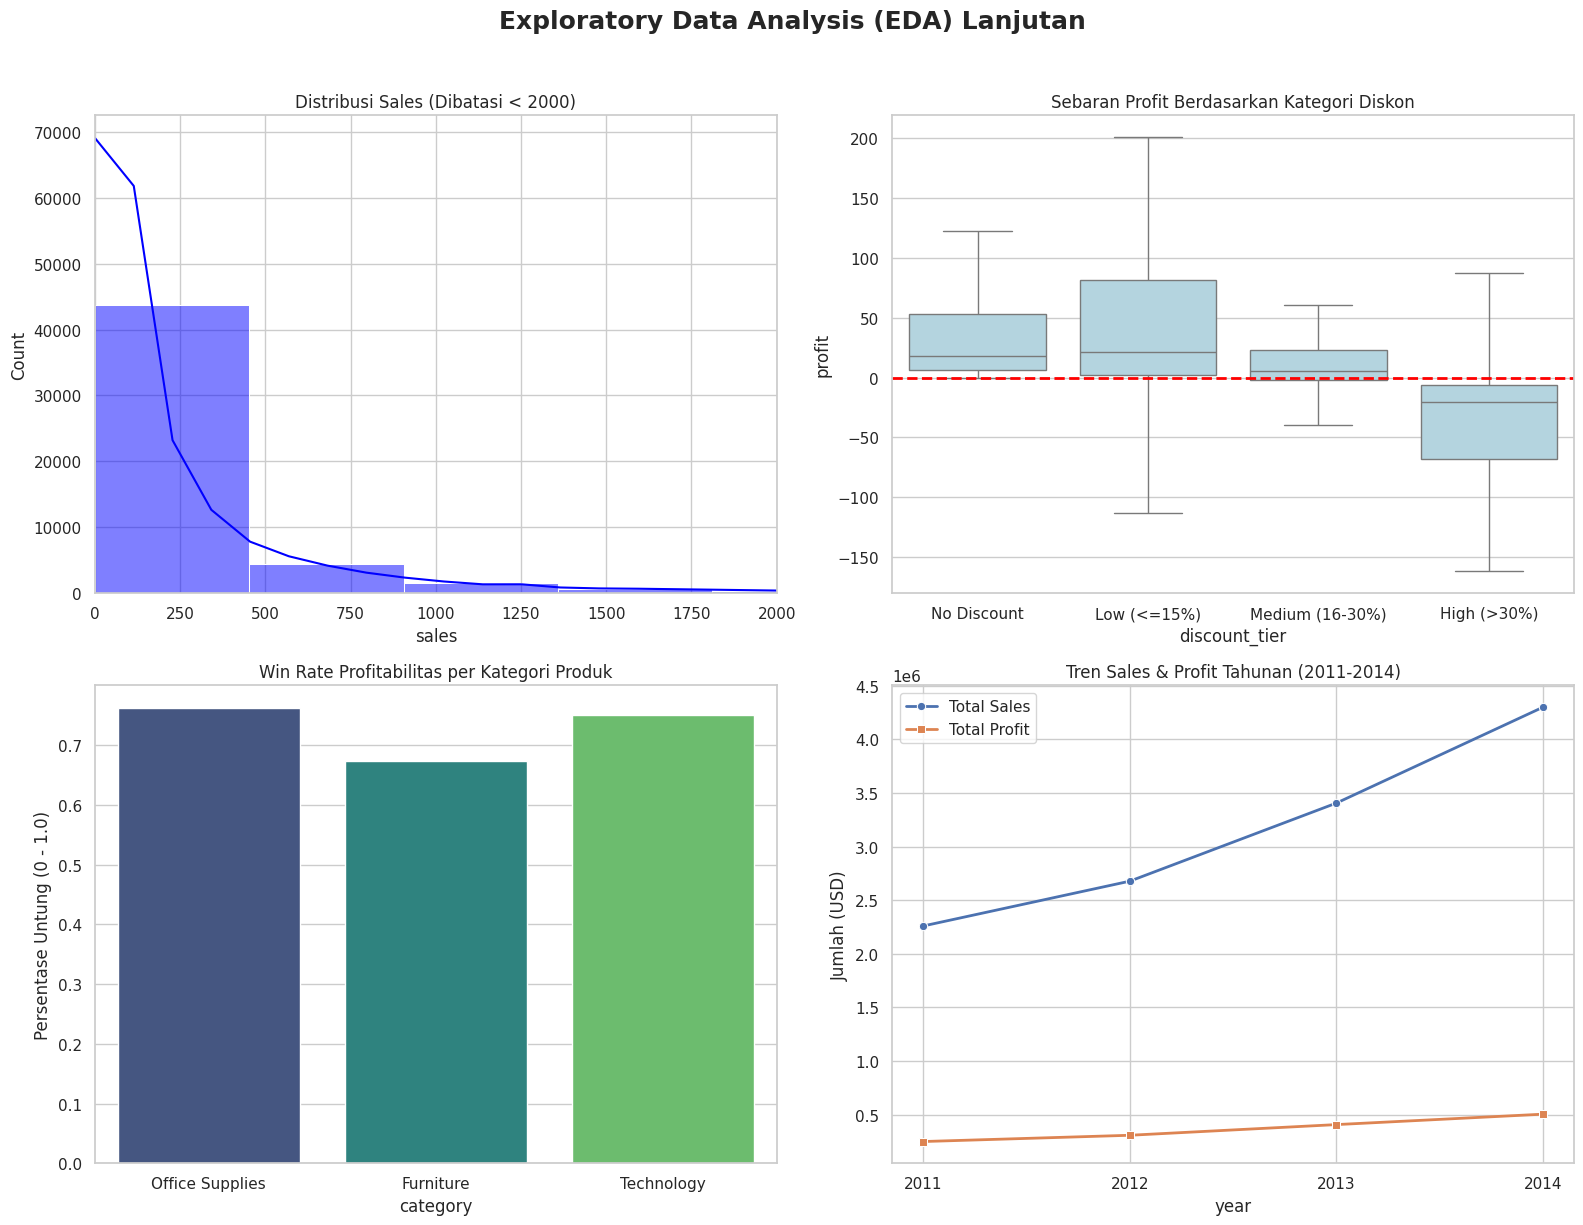

In [9]:
# NOTE: 'discount_tier' dibuat lebih awal di sini agar bisa dipakai untuk EDA.
# Definisi resmi & final feature engineering-nya tetap ada di Bagian 4 (Preprocessing).
def categorize_discount(d):
    if d == 0:
        return 'No Discount'
    elif d <= 0.15:
        return 'Low (<=15%)'
    elif d <= 0.30:
        return 'Medium (16-30%)'
    else:
        return 'High (>30%)'

if 'discount_tier' not in df.columns:
    df['discount_tier'] = df['discount'].apply(categorize_discount)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")

# Membuat kanvas besar untuk menampung 4 grafik sekaligus
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Exploratory Data Analysis (EDA) Lanjutan', fontsize=18, fontweight='bold', y=1.02)

# --- 1. HISTOGRAM: Distribusi Sales dan Profit ---
# Menunjukkan bahwa data sangat skewed (miring) dan banyak outlier
sns.histplot(df['sales'], bins=50, ax=axes[0, 0], color='blue', kde=True)
axes[0, 0].set_title('Distribusi Sales (Dibatasi < 2000)', fontsize=12)
axes[0, 0].set_xlim(0, 2000) # Dibatasi agar bentuknya terlihat jelas

# --- 2. BOXPLOT: Discount Tier vs Profit ---
sns.boxplot(x='discount_tier', y='profit', data=df, 
            order=['No Discount', 'Low (<=15%)', 'Medium (16-30%)', 'High (>30%)'], 
            ax=axes[0, 1], color='lightblue', showfliers=False) # <--- Tambahin showfliers=False
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_title('Sebaran Profit Berdasarkan Kategori Diskon', fontsize=12)

# --- 3. BAR CHART: Profitability Rate by Category ---
sns.barplot(x='category', y='is_profitable', data=df, ax=axes[1, 0], 
            hue='category', palette='viridis', legend=False, errorbar=None)
axes[1, 0].set_title('Win Rate Profitabilitas per Kategori Produk', fontsize=12)
axes[1, 0].set_ylabel('Persentase Untung (0 - 1.0)')

# --- 4. TIME TREND: Sales dan Profit per Tahun ---
# Memastikan order_date berformat datetime dan mengambil tahunnya
df['order_date'] = pd.to_datetime(df['order_date'])
df['year'] = df['order_date'].dt.year

# Mengelompokkan data berdasarkan tahun
df_trend = df.groupby('year')[['sales', 'profit']].sum().reset_index()

sns.lineplot(x='year', y='sales', data=df_trend, marker='o', ax=axes[1, 1], label='Total Sales', linewidth=2)
sns.lineplot(x='year', y='profit', data=df_trend, marker='s', ax=axes[1, 1], label='Total Profit', linewidth=2)
axes[1, 1].set_title('Tren Sales & Profit Tahunan (2011-2014)', fontsize=12)
axes[1, 1].set_xticks([2011, 2012, 2013, 2014])
axes[1, 1].set_ylabel('Jumlah (USD)')

plt.tight_layout()
plt.show()

### Business Insights dari EDA Lanjutan

Empat visualisasi di atas memberikan beberapa temuan tambahan yang memperkuat rumusan masalah:

1. **Distribusi Sales Sangat Skewed:** Histogram menunjukkan mayoritas transaksi bernilai kecil (di bawah $250), dengan ekor panjang ke kanan berupa sejumlah kecil transaksi bernilai sangat besar. Ini mengonfirmasi bahwa target `sales` untuk model Regresi memiliki outlier signifikan, yang perlu dipertimbangkan saat memilih algoritma dan metrik evaluasi (RMSE akan lebih sensitif terhadap outlier ini dibanding MAE).

2. **Diskon Tinggi = Kerugian Konsisten:** Boxplot `discount_tier` vs `profit` menunjukkan pola yang sangat jelas — kategori 'No Discount' dan 'Low' secara konsisten menghasilkan profit positif, sementara kategori 'Medium' dan terutama 'High (>30%)' mayoritas berada di bawah garis impas (profit negatif). Ini memperkuat temuan korelasi sebelumnya dan menjadi dasar kuat bagi model Klasifikasi.

3. **Furniture adalah Kategori Paling Berisiko:** Win rate profitabilitas per kategori menunjukkan Office Supplies (~76%) dan Technology (~74%) jauh lebih konsisten menghasilkan untung dibanding Furniture (~67%). Ini insight bisnis yang actionable — tim sales mungkin perlu lebih berhati-hati memberikan diskon besar pada kategori Furniture.

4. **Sales Tumbuh, tapi Margin Menipis:** Tren tahunan (2011-2014) menunjukkan total sales naik signifikan dari sekitar $2.25 juta menjadi $4.3 juta, hampir dua kali lipat. Namun total profit hanya naik dari sekitar $0.25 juta menjadi $0.5 juta pada periode yang sama — pertumbuhan profit jauh tidak sebanding dengan pertumbuhan sales, mengindikasikan margin keuntungan yang semakin menipis seiring waktu, kemungkinan besar akibat strategi diskon yang semakin agresif.

## 4. Data Preprocessing & Feature Engineering
Pada tahap ini, kita akan membersihkan data dari kolom yang tidak relevan (noise), memperbaiki tipe data tanggal, dan menciptakan fitur-fitur baru (derived features) untuk meningkatkan performa model Machine Learning.

In [10]:
import pandas as pd
import numpy as np

# A. MEMBUANG DATA YANG TIDAK RELEVAN (Noise)
# Membuang 'row_id' karena hanya berupa nomor urut dan tidak memiliki nilai prediksi bisnis
if 'row_id' in df.columns:
    df = df.drop(columns=['row_id'])

# B. MEMPERBAIKI FORMAT TANGGAL
# Mengubah teks (object) menjadi format Datetime resmi
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

# C. MENCIPTAKAN FITUR BARU (Feature Engineering)

# 1. Fitur 'delivery_duration': Selisih hari dari pesanan masuk sampai dikirim
df['delivery_duration'] = (df['ship_date'] - df['order_date']).dt.days

# 2. Fitur 'profit_margin': Rasio keuntungan terhadap total omzet
# np.where digunakan untuk mencegah error (pembagian dengan nol) jika ada sales bernilai 0
df['profit_margin'] = np.where(df['sales'] == 0, 0, df['profit'] / df['sales'])

# 3. Fitur 'discount_tier': Mengelompokkan diskon untuk mempermudah model Klasifikasi
def categorize_discount(d):
    if d == 0:
        return 'No Discount'
    elif d <= 0.15:
        return 'Low (<=15%)'
    elif d <= 0.30:
        return 'Medium (16-30%)'
    else:
        return 'High (>30%)' # Sesuai temuan EDA: titik rawan kerugian

df['discount_tier'] = df['discount'].apply(categorize_discount)

# Menampilkan 5 baris pertama khusus untuk melihat hasil kolom baru kita
df[['order_date', 'ship_date', 'delivery_duration', 'profit_margin', 'discount', 'discount_tier']].head()

,order_date,ship_date,delivery_duration,profit_margin,discount,discount_tier
0,2014-10-02,2014-10-06,4,0.350769,0.0,No Discount
1,2012-10-15,2012-10-20,5,0.360000,0.0,No Discount
2,2012-10-15,2012-10-20,5,0.280207,0.0,No Discount
3,2012-10-15,2012-10-20,5,0.141714,0.0,No Discount
4,2012-10-15,2012-10-20,5,0.158889,0.0,No Discount


In [11]:
from sklearn.model_selection import train_test_split

# 1. ENCODING: Mengubah teks menjadi angka (One-Hot Encoding)
kolom_teks = ['discount_tier'] 
df_ml = pd.get_dummies(df, columns=kolom_teks, drop_first=True)

# 2. SELEKSI FITUR (X) DAN TARGET (y) UNTUK MODEL KLASIFIKASI
fitur_pilihan = ['discount', 'shipping_cost', 'quantity', 'delivery_duration']
kolom_dummy = [col for col in df_ml.columns if 'discount_tier_' in col] 
X = df_ml[fitur_pilihan + kolom_dummy]

# y = Target yang ingin diprediksi mesin
y = df_ml['is_profitable']

# 3. TRAIN-TEST SPLIT: Membelah dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data siap! Proporsi pembagian:")
print(f"Data Latih (Train) : {X_train.shape[0]} baris")
print(f"Data Uji (Test)    : {X_test.shape[0]} baris")

Data siap! Proporsi pembagian:
Data Latih (Train) : 41032 baris
Data Uji (Test)    : 10258 baris
